# SpikeInterface Processing Pipeline for Tetrodes & Neuronexus Probe
### Jake Swann

##### This is a notebook which takes raw Axona recordings (1 .set and 1 .bin file per recording), loads them as a [SpikeInterface](https://github.com/SpikeInterface) object & attaches probe geometry, spike sorts using Klusta, and allows curation of the output in [phy](https://github.com/cortex-lab/phy/)
##### Code is also available to handle non-Klusta sorters [here](#non-klusta)
##### **NB** This requires a Python 3.7 environment with various dependencies installed, including Klusta version 0.95.0, SpikeInterface, and phy. There is code to install most of these from within the notebook: [Install Dependencies](#install-dependencies)
##### It is currently set up to handle a single input file at a time, set manually

### To Do List:
##### - Incorporate handling multiple files in a loop from a spreadsheet of all recordings
##### - Handle concatenating multiple recordings in a single session to sort together, and allow subsequent separation

- Tetrodes: ensure correct marking of which cells come from which tetrodes to allow comparison with Tint
- Tetrodes: work out the best way to split tetrodes for sorting and curation
    - Possible solution: make into a single probe with 8 shanks
    
#### - Set up some sort of spike sorter comparison
---
    
    
    

#### Import all the necessary spikeinterface packages (some currently unused)

In [1]:
import spikeinterface as si
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.postprocessing as spost
import spikeinterface.qualitymetrics as sqm
import spikeinterface.comparison as sc
import spikeinterface.exporters as sexp
import spikeinterface.widgets as sw
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
%matplotlib widget

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) #gets rid of some annoying warnings

#### Load data & get basic information about recording

In [2]:
## Load Tetrode Data
# base_folder = Path("/data/isabella/jake/recording_data/r1299/2023-01-24/")
# recording = se.read_axona(f"{base_folder}/2023-01-24_r1299_t-maze_2_raw.set")
# electrode_type = 'tetrode' # 'probe' or 'tetrode'
# tetrode_count = 8

## Load Probe Data
base_folder = Path('/home/isabella/Documents/isabella/klusta_testdata')
recording = se.read_axona(f"{base_folder}/220624a_famBox.set")
electrode_type = 'probe' # 'probe' or 'tetrode'

## Get some basic information about the recording
fs = recording.get_sampling_frequency()
num_chan = recording.get_num_channels()
num_segments = recording.get_num_segments()
duration = recording.get_total_duration()

## Invert trace if necessary
# recording = spre.scale(recording, gain=-1)

print(f'Number of channels: {num_chan}')
print(f'Total Duration: {duration} seconds')
print(f"Number of segments: {num_segments}")
print(f'Sampling frequency: {fs} Hz')


Number of channels: 64
Total Duration: 900.0625 seconds
Number of segments: 1
Sampling frequency: 48000.0 Hz


#### Generate tetrodes or load probe and assign to recordong

32-channel probe recording loaded from previous preprocessing
BinaryFolderRecording: 32 channels - 1 segments - 48.0kHz - 900.062s


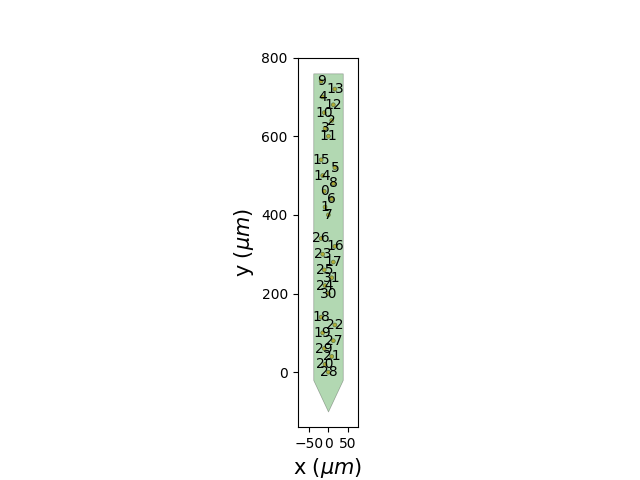

In [3]:
from probeinterface import read_prb
from probeinterface.plotting import plot_probe, plot_probe_group
import probeinterface.probe

if electrode_type == 'tetrode':
    probe = read_prb('/home/isabella/Documents/isabella/klusta_testdata/spikeinterface/8_tetrodes.prb') #Load probe
elif electrode_type == 'probe':
    probe = read_prb('/home/isabella/Documents/isabella/klusta_testdata/spikeinterface/4x8_buzsaki_oneshank.prb') #Load probe
else:
    raise ValueError('Electrode type is set wrong, please set to either "probe" or "tetrode"')
    
plot_probe_group(probe, with_channel_index = True)
#plt.savefig(f'{base_folder}/probe_layout.png')

if (base_folder / "preprocessed").is_dir():
    recording = si.load_extractor(base_folder / "preprocessed")
    print(f'32-channel {electrode_type} recording loaded from previous preprocessing')
    print(recording)
else:
    channel_ids = recording.get_channel_ids()
    recording = recording.channel_slice(channel_ids=channel_ids[:32]) #Cut out empty channels 33-64

    ## Currently necessary as the probe is being treated as a single shank
    ## This turns the probe object from ProbeGroup to Probe
    singleProbe = probeinterface.Probe.from_dict(probe.to_dict()['probes'][0])
    recording = recording.set_probe(singleProbe)

    recording_saved = recording.save(folder=base_folder / "preprocessed")
    print('Recording preprocessed and saved')


#### Sort using klusta

In [ ]:
## Load sorted file if it already exists, otherwise apply a sorting algorithm to recording,
## then aggregate into a single recording object and save
## N.B. tetrodes are sorted together, but as separate channel groups

sorting_path = Path(f'{base_folder}/sorting') # Can be changed if you want to hold on to multiple sorts

if (sorting_path).is_dir():
    sorting = si.load_extractor(sorting_path / 'sort')
    print(f"Sorting loaded from file {sorting_path}")

else:
    sorting = ss.run_sorter('klusta', recording, output_folder=f"{sorting_path}", verbose = True, docker_image = True)
    sorting = sorting.remove_empty_units()
    
    print('\nSorting Complete\n', sorting, '\nKlusta found', len(sorting.get_unit_ids()), 'non-empty units')
    sorting_saved = sorting.save(folder=sorting_path / 'sort')
    print(f'Sorting saved to {sorting_path}/sort')

print(sorting)
raster = sw.plot_rasters(sorting)

Starting container
Installing spikeinterface==0.95.0 in spikeinterface/klusta-base
Running klusta sorter inside spikeinterface/klusta-base


In [ ]:
#Run phy on klusta output
import os
import phy.apps.kwik
os.environ["QTWEBENGINE_CHROMIUM_FLAGS"] = "--single-process"

## If tetrodes sorted separately, change channel_group to choose tetrode to display in phy
phy.apps.kwik.kwik_gui(sorting_path/'recording.kwik', channel_group=None, clustering=None)

---
## Currently unused code:
<a id="non-klusta"></a>
#### For use with non-phy-integrated sorters:

In [ ]:
## Highpass filter and reference data, then extract waveforms for use in spikeinterface GUI
## If using klusta, the same thing can be viewed using phy with the blocks above
## This is more useful when using other sorters

# recording = si.load_extractor(base_folder / "preprocessed")
# recording_to_process = recording
# recording_f = spre.bandpass_filter(recording_to_process, freq_min=300, freq_max=6000)
# recording_cmr = spre.common_reference(recording_f, reference='global', operator='median')
# fs = recording_cmr.get_sampling_frequency()

# sorting = si.load_extractor(sorting_path / 'sort')

# we = si.extract_waveforms(recording_cmr, sorting, folder=base_folder / "waveforms", 
#                           load_if_exists=False, overwrite=True)
# print(we)

# # Export to phy
# sexp.export_to_phy(we, output_folder=base_folder / 'phy', 
#           compute_amplitudes=True, compute_pc_features=True, copy_binary=True, peak_sign = 'neg', verbose = True)

# # Run phy on spikeinterface waveform output
# %cd {base_folder}
# !phy template-gui phy/params.py



## Create waveform GUI as webpage, requires some setup steps on a new machine
## Found here: https://spikeinterface.readthedocs.io/en/latest/modules/widgets.html#sorting-view

# import kachery_cloud as kcl
# kcl.init()
# waveforms0 = we.get_waveforms(unit_id=0)
# print(f"Waveforms shape: {waveforms0.shape}")
# template0 = we.get_template(unit_id=0)
# print(f"Template shape: {template0.shape}")
# all_templates = we.get_all_templates()
# print(f"All templates shape: {all_templates.shape}")
# correlograms = spost.compute_correlograms(we)
# amps = spost.compute_spike_amplitudes(we)
# locs = spost.compute_unit_locations(we)
# sim = spost.compute_template_similarity(we)
# sw.plot_sorting_summary(we, backend='sortingview')

In [ ]:
## Recording utils
# recording.annotate(is_filtered=False)
# channel_ids = recording.get_channel_ids()
# print(f'Channel ids: {channel_ids}')

#### Code to sort using Klusta by individual tetrodes

In [ ]:
#         sortings = {}
#         for group, sub_recording in recordings.items():
#             sorting = ss.run_sorter('klusta', sub_recording, output_folder=f"{base_folder}/sorting", verbose = False, docker_image = False)
#             sortings[group] = sorting
#             print(f"Tetrode {group+1} of {tetrode_count} Done!")
        
#         for i in list(sortings):
#             if i == 0:
#                 sortings_agg = sortings[0]
#             else:
#                 sortings_agg = si.aggregate_units([sortings_agg, sortings[i]])
#         sorting = sortings_agg

## Plot raster plots per tetrode
# for i in range(1,len(sortings)):
#     raster = sw.plot_rasters(sortings)
#     plt.savefig(f'C:/Users/jakes/Documents/recording_data/r1299/2023-01-24/plots/raster_tetrode{i}.png')

#### Code to generate tetrodes for sorting on individual tetrodes

In [ ]:
## Generate tetrodes (if tetrode recording) and assign to recording channels
# if electrode_type == 'tetrode':
#     ## Function to produce tetrode objects and assign them to a ProbeGroup
#     from utils import generate_tetrodes 
    
#     if (base_folder / "preprocessed").is_dir():
#         recording = si.load_extractor(base_folder / "preprocessed")
#         print('Tetrode recording loaded from previous preprocessing')
#         generate_tetrodes(tetrode_count)

        
#     else:
#         recording = recording.set_probegroup(generate_tetrodes(tetrode_count), group_mode='by_probe')
#         recording_saved = recording.save(folder=base_folder / "preprocessed")
#         print('Tetrode recording saved to "preprocessed" folder')
    
#     recordings = recording.split_by(property='group', outputs='dict')
#     print(f'Recording split into {tetrode_count} tetrodes')

<a id="install-dependencies"></a>
## Install Dependencies

In [ ]:
## Install spike interface if not already installed
# !pip install spikeinterface

## Install klusta and its dependencies if not already installed
# !pip install Cython h5py tqdm
# !pip install click klusta klustakwik2

## Install phy and dependencies if not already installed
# !conda activate si_env
# !pip install PyQt5==5.12.3
# !pip install pyqtwebengine==5.12.1
# !pip install phy --pre --upgrade

## Check which sorters are installed locally
# ss.installed_sorters()